In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve().parent

In [2]:
import pandas as pd
import numpy as np

df_train = pd.read_csv(f"{ROOT}/data/processed/df_train.csv")
df_test = pd.read_csv(f"{ROOT}/data/processed/df_test.csv")

--- Final Test Results ---
Accuracy:  0.7927
ROC-AUC:   0.7961

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87     12184
           1       0.38      0.53      0.44      2226

    accuracy                           0.79     14410
   macro avg       0.64      0.69      0.66     14410
weighted avg       0.83      0.79      0.81     14410


Confusion Matrix:
[[10234  1950]
 [ 1037  1189]]


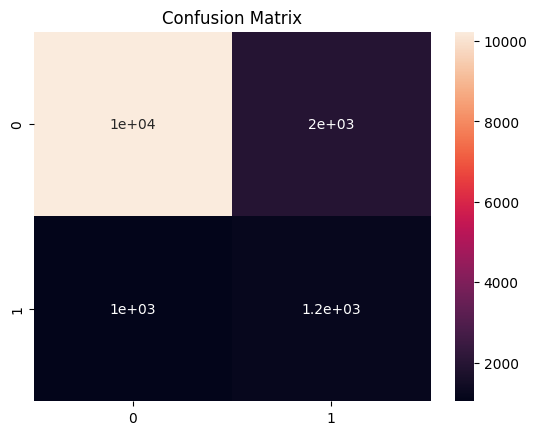

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score

# 1. Prepare X and y
# Ensure columns match exactly between train and test
X_train = df_train.drop(columns=['booking_complete'])
y_train = df_train['booking_complete']

X_test = df_test.drop(columns=['booking_complete'])
y_test = df_test['booking_complete']

# 2. Final Fit
# Using 'balanced' is key so the model doesn't ignore your 8k minority cases
rf_initial = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_initial.fit(X_train, y_train)

# 3. Predict
y_probs = rf_initial.predict_proba(df_test.drop(columns=['booking_complete']))[:, 1]
y_pred = rf_initial.predict(X_test)

# 4. Evaluation Metrics
print("--- Final Test Results ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
sns.heatmap(conf_matrix, annot=True)
plt.title("Confusion Matrix")
plt.show()

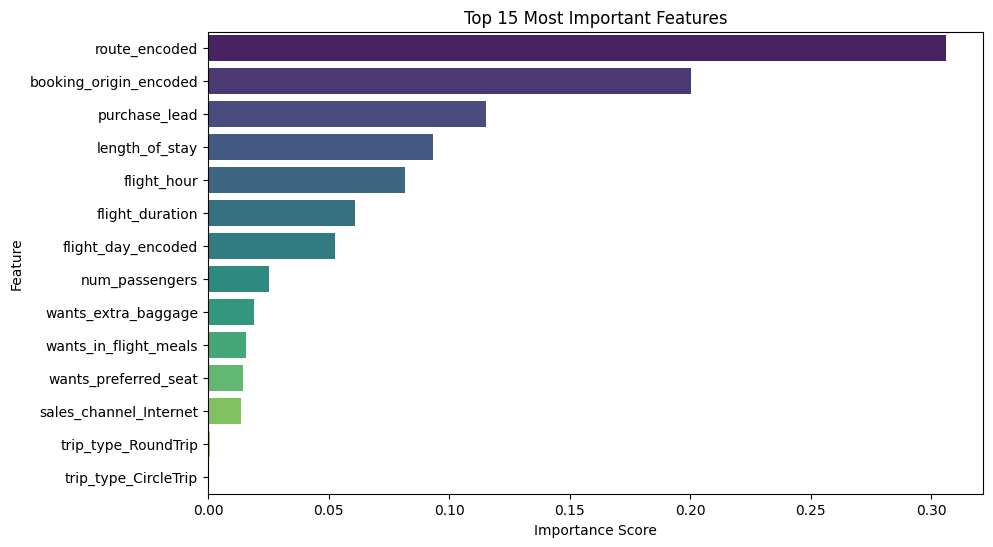

In [4]:
# 1. Get importance from your best model
importances = rf_initial.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

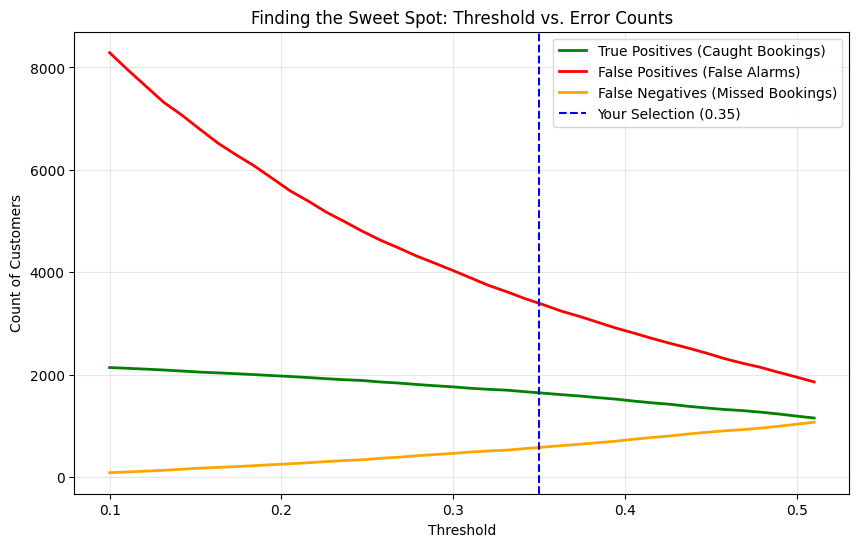

In [5]:
thresholds = np.linspace(0.1, 0.51, 40)
tps, fps, fns = [], [], []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tps.append(tp)
    fps.append(fp)
    fns.append(fn)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, tps, label='True Positives (Caught Bookings)', color='green', lw=2)
plt.plot(thresholds, fps, label='False Positives (False Alarms)', color='red', lw=2)
plt.plot(thresholds, fns, label='False Negatives (Missed Bookings)', color='orange', lw=2)

plt.axvline(x=0.35, color='blue', linestyle='--', label='Your Selection (0.35)')
plt.title('Finding the Sweet Spot: Threshold vs. Error Counts')
plt.xlabel('Threshold')
plt.ylabel('Count of Customers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Best Threshold (Youden's J): 0.3288
Maximum J-statistic: 0.4675


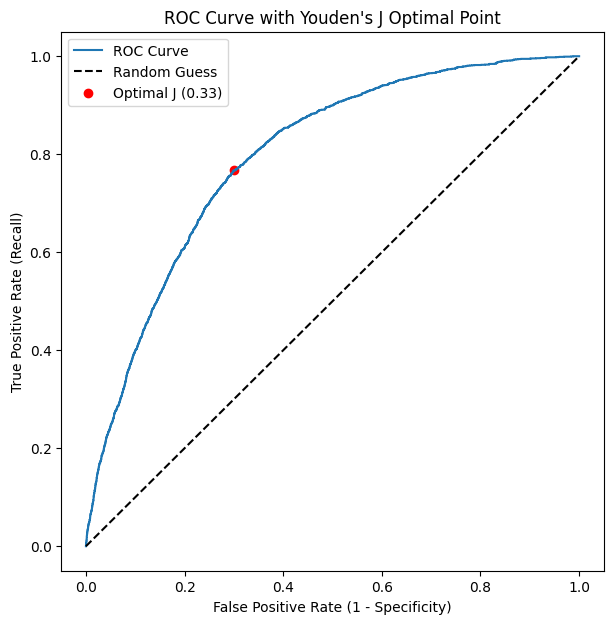

In [6]:
from sklearn.metrics import roc_curve

# 1. Get the False Positive Rate, True Positive Rate, and Thresholds from the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 2. Calculate Youden's J for every threshold
# J = Recall (TPR) - FPR
j_scores = tpr - fpr

# 3. Find the index of the maximum J score
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (Youden's J): {best_threshold:.4f}")
print(f"Maximum J-statistic: {j_scores[best_idx]:.4f}")

# 4. (Optional) Visualize where this point sits on the ROC Curve

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Optimal J ({best_threshold:.2f})')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve with Youden\'s J Optimal Point')
plt.legend()
plt.show()

In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33621 entries, 0 to 33620
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   num_passengers          33621 non-null  int64  
 1   purchase_lead           33621 non-null  int64  
 2   length_of_stay          33621 non-null  int64  
 3   flight_hour             33621 non-null  int64  
 4   wants_extra_baggage     33621 non-null  int64  
 5   wants_preferred_seat    33621 non-null  int64  
 6   wants_in_flight_meals   33621 non-null  int64  
 7   flight_duration         33621 non-null  float64
 8   route_encoded           33621 non-null  float64
 9   booking_origin_encoded  33621 non-null  float64
 10  flight_day_encoded      33621 non-null  float64
 11  sales_channel_Internet  33621 non-null  int64  
 12  trip_type_CircleTrip    33621 non-null  int64  
 13  trip_type_RoundTrip     33621 non-null  int64  
dtypes: float64(4), int64(10)
memory usage:

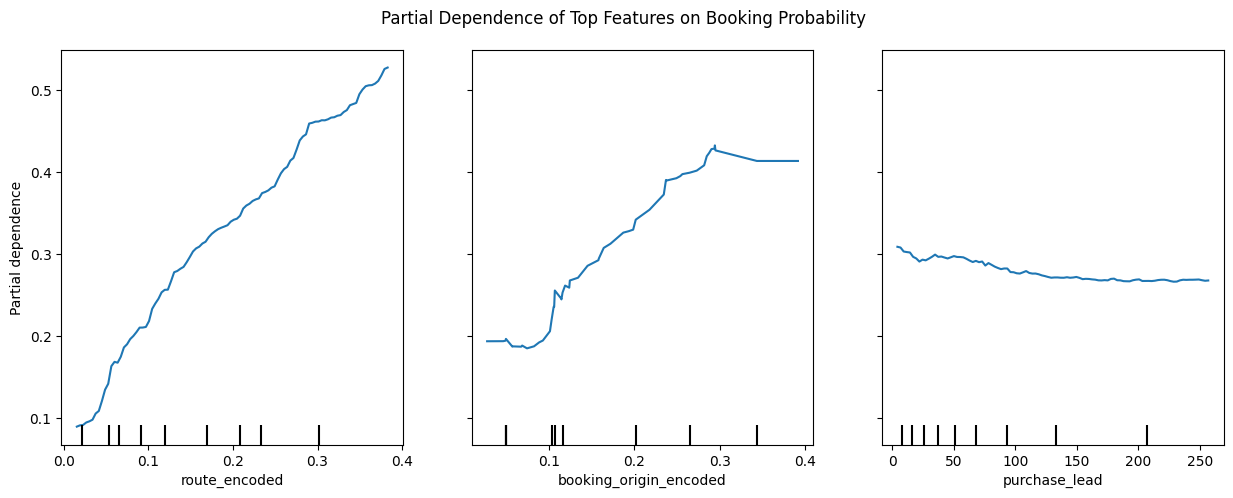

In [8]:
from sklearn.inspection import PartialDependenceDisplay


# 1. Select the features you want to inspect
# It's best to look at your top performers
features_to_plot = ['route_encoded', 'booking_origin_encoded', 'purchase_lead']

X_train_temp = X_train
X_train_temp['purchase_lead'] = X_train_temp['purchase_lead'].astype('float64')
# 2. Generate the plot
fig, ax = plt.subplots(figsize=(15, 5))
display = PartialDependenceDisplay.from_estimator(
    rf_initial, 
    X_train_temp, 
    features=features_to_plot, 
    kind='average', # This shows the overall trend
    ax=ax
)

plt.suptitle('Partial Dependence of Top Features on Booking Probability')
plt.subplots_adjust(top=0.9)
plt.show()

--- Final Test Results ---
Accuracy:  0.7109
ROC-AUC:   0.7961

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     12184
           1       0.32      0.77      0.45      2226

    accuracy                           0.71     14410
   macro avg       0.63      0.73      0.63     14410
weighted avg       0.85      0.71      0.75     14410


Confusion Matrix:
[[8537 3647]
 [ 519 1707]]


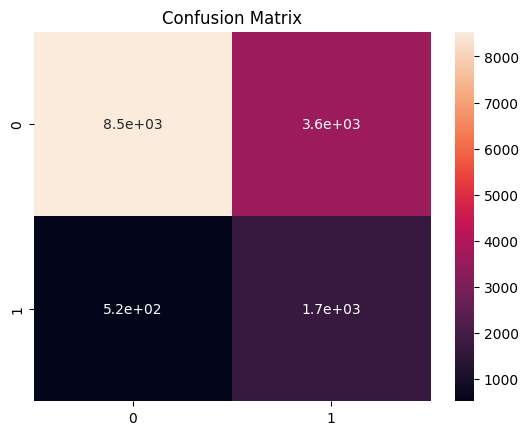

In [9]:
# 2. Final Fit
# Using 'balanced' is key so the model doesn't ignore your 8k minority cases
rf_final = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

# 3. Predict
y_probs = rf_final.predict_proba(df_test.drop(columns=['booking_complete']))[:, 1]
y_pred_threshold = (y_probs >= 0.3288).astype(int)

# 4. Evaluation Metrics
print("--- Final Test Results ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_threshold):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_threshold))
print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred_threshold)
print(conf_matrix)
sns.heatmap(conf_matrix, annot=True)
plt.title("Confusion Matrix")
plt.show()

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 1. Define the "Search Space"
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

spw = round((y_train == 0).sum() / (y_train == 1).sum(),4)
# 2. Initialize the model with fixed parameters (like SPW)
xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42
)

# 3. Setup the Grid Search
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,            # 3-fold cross-validation
    verbose=1,
    n_jobs=-1        # Use all CPU cores
)

# 4. Run the Search
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 135 candidates, totalling 405 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 400}
Best Score: 0.8126


In [11]:
xgb_clf = XGBClassifier(
    n_estimators = 400,
    max_depth = 6,
    learning_rate = 0.01,
    colsample_bytree = 0.7,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42,
)


xgb_clf.fit(X_train, y_train)
y_probs_xgb = xgb_clf.predict_proba(X_test)[:, 1]
print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_probs_xgb):.4f}")


# 1. Define your threshold (using the Youden's J result or your manual 0.35)
threshold = 0.3288

# 2. Convert probabilities to binary predictions
y_pred_xgb = (y_probs_xgb >= threshold).astype(int)

# 3. Now plot the confusion matrix using y_pred_xgb
from sklearn.metrics import confusion_matrix
print(f"Classification Report:\n{classification_report(y_test, y_pred_xgb)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")

XGBoost ROC-AUC: 0.7958
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.55      0.70     12184
           1       0.26      0.88      0.41      2226

    accuracy                           0.60     14410
   macro avg       0.61      0.72      0.55     14410
weighted avg       0.85      0.60      0.65     14410

Confusion Matrix:
[[6665 5519]
 [ 258 1968]]
